# Notebook 12 – K-Means Clustering
Using `data.csv` (retail orders)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
%matplotlib inline

In [2]:
df = pd.read_csv('data.csv', encoding='latin1')
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
customers = df.groupby('CustomerID').agg(
    Spend=('TotalPrice', 'sum'),
    Quantity=('Quantity', 'sum')
).reset_index().sample(n=300, random_state=1)
X = StandardScaler().fit_transform(customers[['Quantity', 'Spend']])
customers.head()

,CustomerID,Spend,Quantity
3092,16565.0,173.70,46
3207,16725.0,781.02,294
2742,16091.0,315.06,154
1030,13739.0,216.90,54
2830,16202.0,365.27,191


## 1. K-Means
**What:** An algorithm that automatically groups data into K clusters based on similarity.
**Example:** Group our customers into clusters by `Quantity` and `Spend`.
**Why:** Lets us find customer groups without any labels.


In [3]:
kmeans = KMeans(n_clusters=3, random_state=1, n_init=10)
customers['Cluster'] = kmeans.fit_predict(X)
customers[['Quantity', 'Spend', 'Cluster']].head()

,Quantity,Spend,Cluster
3092,46,173.70,0
3207,294,781.02,0
2742,154,315.06,0
1030,54,216.90,0
2830,191,365.27,0


## 2. Centroids
**What:** The center point of each cluster — like the "average" customer in that group.
**Example:** Each of our 3 clusters has one centroid point.
**Why:** The centroid represents what a "typical" member of that cluster looks like.


In [4]:
print("Centroids (scaled values):")
print(kmeans.cluster_centers_)

Centroids (scaled values):
[[-0.17490896 -0.19150612]
 [13.44459195 11.80347764]
 [ 1.76775039  2.08133655]]


## 3. Distance
**What:** How far apart two points are. K-Means uses distance to decide which cluster a point belongs to.
**Example:** A customer is placed in the cluster whose centroid is closest to them.
**Why:** Distance is the "closeness" rule K-Means uses to form groups.


In [5]:
point = X[0]
distances = np.linalg.norm(kmeans.cluster_centers_ - point, axis=1)
print("Distance to each centroid:", distances)
print("Closest cluster:", distances.argmin())

Distance to each centroid: [ 0.3708176  18.51938257  3.35755683]
Closest cluster: 0


## 4. Cluster Assignment
**What:** Giving each data point the label of its nearest centroid.
**Example:** Every customer gets a `Cluster` number (0, 1, or 2) — the `Cluster` column we made in Step 1.
**Why:** This is literally how the grouping happens — nearest centroid wins.


In [6]:
customers['Cluster'].value_counts()

Cluster
0    279
2     20
1      1
Name: count, dtype: int64

## 5. Centroid Update
**What:** After points are assigned, K-Means moves each centroid to the average position of its new members.
**Example:** If a cluster gains a big spender, its centroid shifts slightly toward higher spend.
**Why:** This keeps the centroid an accurate "center" as cluster membership changes.


In [7]:
cluster0_points = X[customers['Cluster'] == 0]
manual_centroid = cluster0_points.mean(axis=0)
print("Manually recalculated centroid for cluster 0:", manual_centroid)
print("KMeans centroid for cluster 0:              ", kmeans.cluster_centers_[0])

Manually recalculated centroid for cluster 0: [-0.17490896 -0.19150612]
KMeans centroid for cluster 0:               [-0.17490896 -0.19150612]


## 6. Iterations
**What:** K-Means repeats "assign points -> update centroids" over and over until things stop changing.
**Example:** Our model ran several rounds internally before settling on final clusters.
**Why:** One pass isn't enough — repeating lets the clusters settle into a stable, good grouping.


In [8]:
print("Number of iterations it took to finish:", kmeans.n_iter_)

Number of iterations it took to finish: 3


## 7. Choosing K
**What:** K is the number of clusters we want. We must choose it — K-Means doesn't decide this by itself.
**Example:** We picked K=3 earlier, but is that the best choice?
**Why:** The wrong K can group very different customers together, or split similar ones apart.


*(We'll answer this properly using the Elbow Method and Silhouette Score below.)*

## 8. Elbow Method
**What:** Try several K values and plot the error (inertia) for each. The "elbow" point (where the drop slows down) is a good K.
**Example:** Testing K = 1 to 8 on our customers.
**Why:** Gives a visual way to pick a reasonable K instead of guessing.


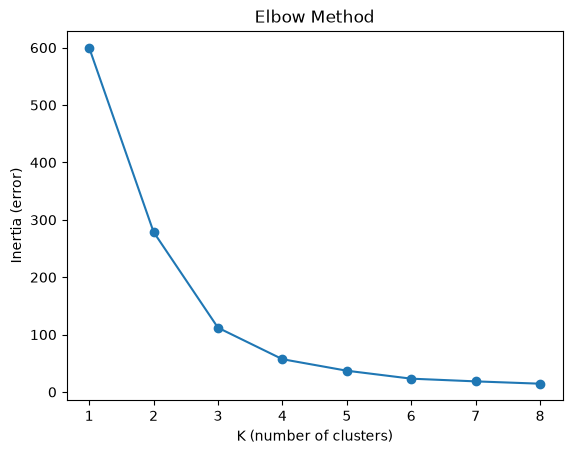

In [9]:
inertias = []
K_range = range(1, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=1, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)
plt.plot(K_range, inertias, marker='o')
plt.xlabel('K (number of clusters)')
plt.ylabel('Inertia (error)')
plt.title('Elbow Method')
plt.show()

## 9. Silhouette Score
**What:** A score (from -1 to 1) showing how well-separated the clusters are. Higher is better.
**Example:** Checking the silhouette score for a few different K values.
**Why:** Backs up the Elbow Method with a clear number, instead of just eyeballing a chart.


In [10]:
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=1, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"K={k} -> Silhouette Score = {score:.3f}")

K=2 -> Silhouette Score = 0.950
K=3 -> Silhouette Score = 0.799
K=4 -> Silhouette Score = 0.693
K=5 -> Silhouette Score = 0.677


## Final Model — Visualize the Resulting Clusters
Based on the Elbow and Silhouette results, we'll go with **K=3** and plot the final clusters with their centroids.


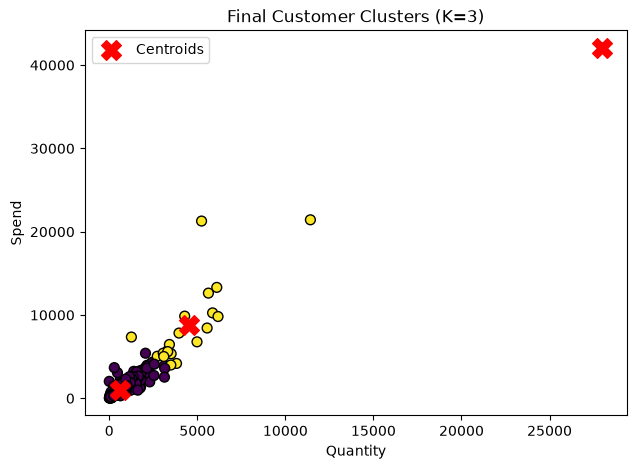

In [12]:
final_kmeans = KMeans(n_clusters=3, random_state=1, n_init=10)
customers['Cluster'] = final_kmeans.fit_predict(X)
plt.figure(figsize=(7, 5))
plt.scatter(customers['Quantity'], customers['Spend'],
            c=customers['Cluster'], cmap='viridis', s=50, edgecolors='k')
scaler = StandardScaler().fit(customers[['Quantity', 'Spend']])
centroids_original = scaler.inverse_transform(final_kmeans.cluster_centers_)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            c='red', marker='X', s=200, label='Centroids')
plt.xlabel('Quantity')
plt.ylabel('Spend')
plt.title('Final Customer Clusters (K=3)')
plt.legend()
plt.show()

## 10. Cluster Interpretation
**What:** Looking at each cluster's typical values to understand what it represents.
**Example:** Checking the average `Quantity` and `Spend` per cluster.
**Why:** Numbers/plots alone aren't useful until we explain what each cluster means in plain terms (e.g., "big spenders" vs "occasional buyers").


In [13]:
customers.groupby('Cluster')[['Quantity', 'Spend']].mean()

,Quantity,Spend
Cluster,,
0,604.777778,1014.304731
1,28004.000000,42055.960000
2,4512.950000,8790.991000


**In plain words**, based on the averages above, we can now describe each cluster — for example:
- **Cluster with high Spend & Quantity** → "Big Spenders"
- **Cluster with low Spend & Quantity** → "Occasional Buyers"
- **Cluster in between** → "Regular Customers"


## Recap
- **K-Means** – groups data into K clusters automatically
- **Centroids** – the center point of each cluster
- **Distance** – decides which cluster a point belongs to
- **Cluster Assignment** – each point joins its nearest centroid
- **Centroid Update** – centroids move to the average of their members
- **Iterations** – repeats assign/update until stable
- **Choosing K** – we must pick the number of clusters
- **Elbow Method** – plot error vs K to spot a good K
- **Silhouette Score** – numeric score for how well-separated clusters are
- **Cluster Interpretation** – explain what each cluster means in plain terms
